In [75]:
import sys
sys.executable

'c:\\Users\\Sujitkumar Bharati\\ITvedant anaconda files\\Graphura\\Graphura Social Media DS-DA Project\\venv\\Scripts\\python.exe'

In [76]:
version = sys.version
print(version)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


# Graphura Instagram Content Intelligence 

#### 1. INTRODUCTION

Project Objective

The objective of this machine learning system is to predict the performance of Instagram posts and support data-driven content planning for Graphura.
Each post is classified into one of three performance categories based on historical engagement rate thresholds:

-High Performance
-Medium Performance
-Low Performance

## 1. Importing essential python libraries 

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 2. Dataset Loading

In [78]:
data = pd.read_csv("Graphura Social Media Data.csv")
data.head()

,Post ID,Platform,Duration (sec),Date,Post type,Views,Reach,Likes,Shares,Follows,Comments,Saves,Hashtag
0,1,Linkedin,NaN,04-11-2025,Image,358,98,13,0,0,0,0,NaN
1,2,Linkedin,NaN,05-11-2025,Image,380,115,19,0,0,0,0,NaN
2,3,Linkedin,NaN,06-11-2025,Image,389,93,11,0,0,0,0,NaN
3,4,Linkedin,NaN,07-11-2025,Carousel,334,78,13,0,0,0,0,NaN
4,5,Linkedin,NaN,08-11-2025,Image,337,81,17,0,0,0,0,NaN


## 3. Data Cleaning & Preprocessing

In [79]:
data.info()
data.isnull().sum()
data.columns = data.columns.str.strip()
data.fillna('0',inplace=True)
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Post ID         175 non-null    int64  
 1   Platform        175 non-null    object 
 2   Duration (sec)  85 non-null     float64
 3   Date            175 non-null    object 
 4   Post type       175 non-null    object 
 5   Views           175 non-null    int64  
 6   Reach           175 non-null    int64  
 7   Likes           175 non-null    int64  
 8   Shares          175 non-null    int64  
 9   Follows         175 non-null    int64  
 10  Comments        175 non-null    int64  
 11  Saves           175 non-null    int64  
 12  Hashtag         84 non-null     object 
dtypes: float64(1), int64(8), object(4)
memory usage: 17.9+ KB


,Post ID,Platform,Duration (sec),Date,Post type,Views,Reach,Likes,Shares,Follows,Comments,Saves,Hashtag
0,1,Linkedin,0,04-11-2025,Image,358,98,13,0,0,0,0,0
1,2,Linkedin,0,05-11-2025,Image,380,115,19,0,0,0,0,0
2,3,Linkedin,0,06-11-2025,Image,389,93,11,0,0,0,0,0
3,4,Linkedin,0,07-11-2025,Carousel,334,78,13,0,0,0,0,0
4,5,Linkedin,0,08-11-2025,Image,337,81,17,0,0,0,0,0


In [80]:
# data["Date"] = pd.to_datetime(
#     data["Date"],
#     format="mixed",
#     dayfirst=True,
#     errors="coerce"
# )

# data = data.copy()
# data["Day"] = data["Date"].dt.day
# data["Month"] = data["Date"].dt.month
# data["Weekday"] = data["Date"].dt.weekday


In [81]:
data["Post type"].fillna(0)

0         Image
1         Image
2         Image
3      Carousel
4         Image
         ...   
170       Image
171    Carousel
172       Image
173       Image
174       Image
Name: Post type, Length: 175, dtype: object

In [82]:
data.columns

Index(['Post ID', 'Platform', 'Duration (sec)', 'Date', 'Post type', 'Views',
       'Reach', 'Likes', 'Shares', 'Follows', 'Comments', 'Saves', 'Hashtag'],
      dtype='object')

In [83]:
data.drop(columns=["Date","Post ID","Duration (sec)"], inplace=True)

In [84]:
data.head()

,Platform,Post type,Views,Reach,Likes,Shares,Follows,Comments,Saves,Hashtag
0,Linkedin,Image,358,98,13,0,0,0,0,0
1,Linkedin,Image,380,115,19,0,0,0,0,0
2,Linkedin,Image,389,93,11,0,0,0,0,0
3,Linkedin,Carousel,334,78,13,0,0,0,0,0
4,Linkedin,Image,337,81,17,0,0,0,0,0


## 4.Feature Engineering`

In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Platform   175 non-null    object
 1   Post type  175 non-null    object
 2   Views      175 non-null    int64 
 3   Reach      175 non-null    int64 
 4   Likes      175 non-null    int64 
 5   Shares     175 non-null    int64 
 6   Follows    175 non-null    int64 
 7   Comments   175 non-null    int64 
 8   Saves      175 non-null    int64 
 9   Hashtag    175 non-null    object
dtypes: int64(7), object(3)
memory usage: 13.8+ KB


In [86]:
data["Hashtag_Count"] = data["Hashtag"].fillna("").str.count("#")

In [87]:
data["Engagement Rate by Reach (%)"] = (
    (
        data["Likes"].fillna(0)
        + data["Comments"].fillna(0)
        + data["Shares"].fillna(0)
        + data["Views"].fillna(0)
        + data["Saves"].fillna(0)
    )
    / data["Reach"].replace(0, np.nan)
) * 100

data["Engagement Rate by Reach (%)"] = data["Engagement Rate by Reach (%)"].clip(upper=100)

In [88]:
data["Engagement Rate by Views (%)"] = (
    (
        data["Likes"].fillna(0)
        + data["Comments"].fillna(0)
        + data["Shares"].fillna(0)
        + data["Reach"].fillna(0)
        + data["Saves"].fillna(0)
    )
    / data["Views"].replace(0, np.nan)
) * 100

data["Engagement Rate by Views (%)"] = data["Engagement Rate by Views (%)"].clip(upper=100)

In [89]:
data["Avg_Engagement_Rate (%)"] = (
    data["Engagement Rate by Reach (%)"] +
    data["Engagement Rate by Views (%)"]
) / 2


In [90]:
data["Avg_Engagement_Rate (%)"].median()

66.89189189189189

In [91]:
print(data[["Engagement Rate by Reach (%)","Engagement Rate by Views (%)", "Avg_Engagement_Rate (%)"]].describe())


       Engagement Rate by Reach (%)  Engagement Rate by Views (%)  \
count                         175.0                    175.000000   
mean                          100.0                     39.150224   
std                             0.0                     19.221596   
min                           100.0                     13.084112   
25%                           100.0                     26.217949   
50%                           100.0                     33.783784   
75%                           100.0                     48.615340   
max                           100.0                     97.183099   

       Avg_Engagement_Rate (%)  
count               175.000000  
mean                 69.575112  
std                   9.610798  
min                  56.542056  
25%                  63.108974  
50%                  66.891892  
75%                  74.307670  
max                  98.591549  


In [92]:
import pandas as pd

bins = [0, 63, 74, 100]
labels = ["Low", "Medium", "High"]

data["Performance_Class"] = pd.cut(
    data["Engagement Rate by Views (%)"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)


In [93]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Platform                      175 non-null    object  
 1   Post type                     175 non-null    object  
 2   Views                         175 non-null    int64   
 3   Reach                         175 non-null    int64   
 4   Likes                         175 non-null    int64   
 5   Shares                        175 non-null    int64   
 6   Follows                       175 non-null    int64   
 7   Comments                      175 non-null    int64   
 8   Saves                         175 non-null    int64   
 9   Hashtag                       175 non-null    object  
 10  Hashtag_Count                 175 non-null    int64   
 11  Engagement Rate by Reach (%)  175 non-null    float64 
 12  Engagement Rate by Views (%)  175 non-null    floa

In [94]:
data.columns

Index(['Platform', 'Post type', 'Views', 'Reach', 'Likes', 'Shares', 'Follows',
       'Comments', 'Saves', 'Hashtag', 'Hashtag_Count',
       'Engagement Rate by Reach (%)', 'Engagement Rate by Views (%)',
       'Avg_Engagement_Rate (%)', 'Performance_Class'],
      dtype='object')

In [95]:
data.head()

,Platform,Post type,Views,Reach,Likes,Shares,Follows,Comments,Saves,Hashtag,Hashtag_Count,Engagement Rate by Reach (%),Engagement Rate by Views (%),Avg_Engagement_Rate (%),Performance_Class
0,Linkedin,Image,358,98,13,0,0,0,0,0,0,100.0,31.005587,65.502793,Low
1,Linkedin,Image,380,115,19,0,0,0,0,0,0,100.0,35.263158,67.631579,Low
2,Linkedin,Image,389,93,11,0,0,0,0,0,0,100.0,26.735219,63.367609,Low
3,Linkedin,Carousel,334,78,13,0,0,0,0,0,0,100.0,27.245509,63.622754,Low
4,Linkedin,Image,337,81,17,0,0,0,0,0,0,100.0,29.080119,64.540059,Low


# Feature Selection

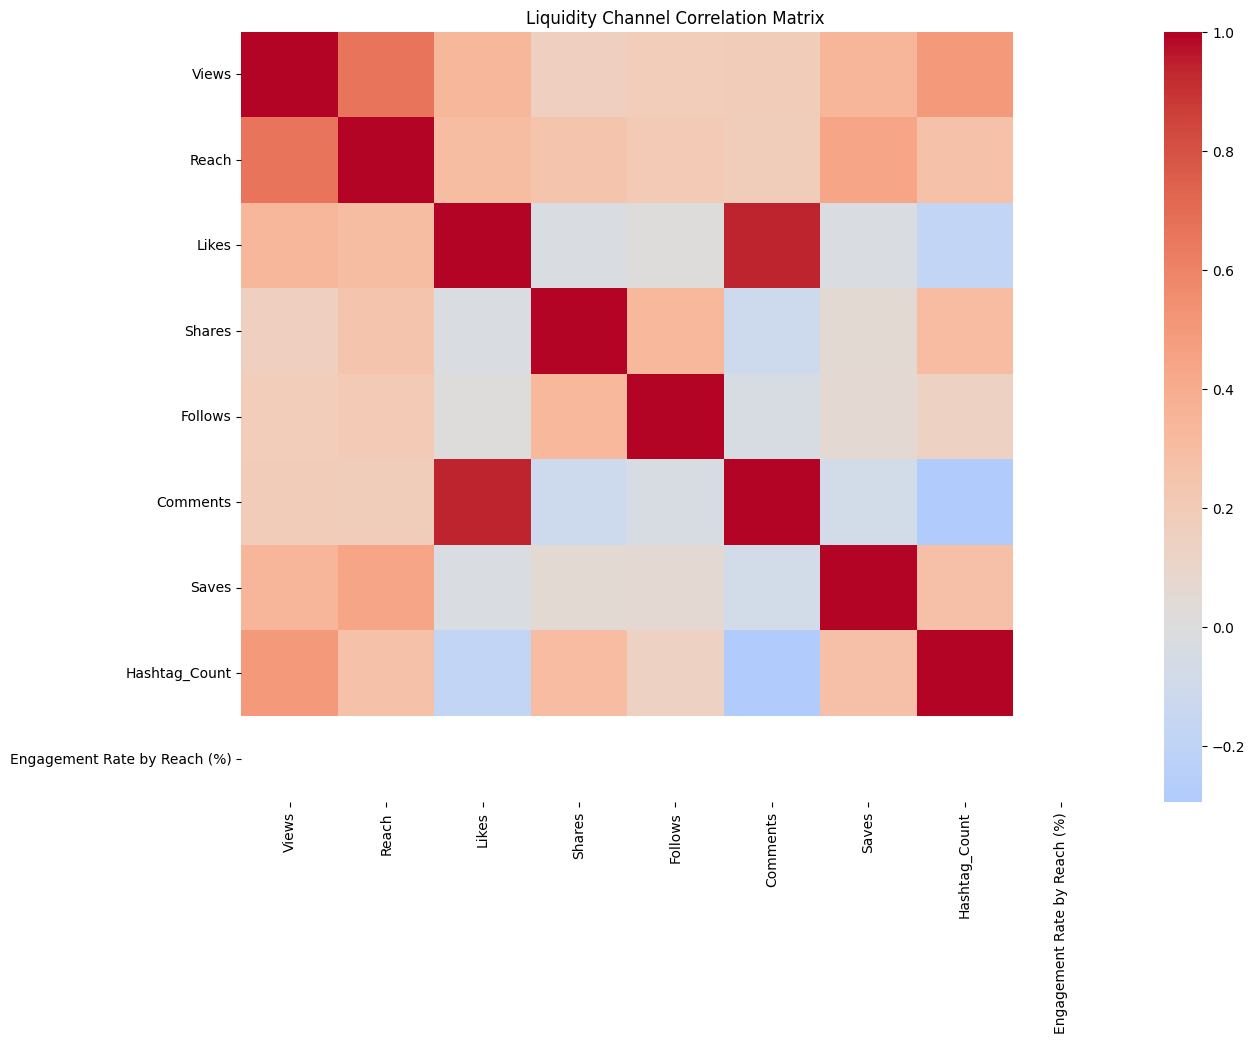

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = data.select_dtypes(include=["int64", "float64"]) \
           .drop(columns=["Hashtag""Engagement Rate by Reach (%)","Engagement Rate by Views (%)", "Avg_Engagement_Rate (%)"], errors="ignore") \
           .corr()


plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Liquidity Channel Correlation Matrix")
plt.show()

In [97]:
data.head()

,Platform,Post type,Views,Reach,Likes,Shares,Follows,Comments,Saves,Hashtag,Hashtag_Count,Engagement Rate by Reach (%),Engagement Rate by Views (%),Avg_Engagement_Rate (%),Performance_Class
0,Linkedin,Image,358,98,13,0,0,0,0,0,0,100.0,31.005587,65.502793,Low
1,Linkedin,Image,380,115,19,0,0,0,0,0,0,100.0,35.263158,67.631579,Low
2,Linkedin,Image,389,93,11,0,0,0,0,0,0,100.0,26.735219,63.367609,Low
3,Linkedin,Carousel,334,78,13,0,0,0,0,0,0,100.0,27.245509,63.622754,Low
4,Linkedin,Image,337,81,17,0,0,0,0,0,0,100.0,29.080119,64.540059,Low


In [98]:
from sklearn.model_selection import train_test_split

xc = data.drop(["Hashtag","Performance_Class","Engagement Rate by Reach (%)","Engagement Rate by Views (%)", "Avg_Engagement_Rate (%)"], axis=1)

yc = data["Performance_Class"]

xctrain, xctest, yctrain, yctest = train_test_split(xc,yc,test_size=0.2,random_state=42,stratify=yc)

In [99]:
xc.columns

Index(['Platform', 'Post type', 'Views', 'Reach', 'Likes', 'Shares', 'Follows',
       'Comments', 'Saves', 'Hashtag_Count'],
      dtype='object')

In [100]:
num_cols = [
    "Views", "Reach", "Likes", "Shares",
    "Follows", "Comments", "Saves", "Hashtag_Count"
]

cat_cols = ["Platform", "Post type"]

target = "Performance_Class"


In [101]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", RobustScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False   # CRITICAL FIX
    ))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])
remainder="drop"


In [102]:
xctrain_processed = preprocessor.fit_transform(xctrain)
xctest_processed = preprocessor.transform(xctest)

# CLASSIFICATION MODELS (post performance category)

#### Model Training, Model Evaluation & Model Training

In [103]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, xctest, yctest, name):
    preds = model.predict(xctest)
    acc = accuracy_score(yctest, preds)
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(yctest, preds))
    
    return acc

## 1. Logistic Regression

In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=200))
])


log_params = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["lbfgs"],
    "model__class_weight": [None, "balanced"]
}


log_grid = GridSearchCV(
    log_pipe,
    log_params,
    cv=5,
    scoring="accuracy"
)

log_grid.fit(xctrain, yctrain)
best_log = log_grid.best_estimator_

evaluate_model(best_log, xctest, yctest, "Logistic Regression")



Logistic Regression
Accuracy: 0.9142857142857143
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         2
         Low       0.94      0.97      0.95        30
      Medium       0.50      0.33      0.40         3

    accuracy                           0.91        35
   macro avg       0.81      0.77      0.78        35
weighted avg       0.90      0.91      0.91        35



0.9142857142857143

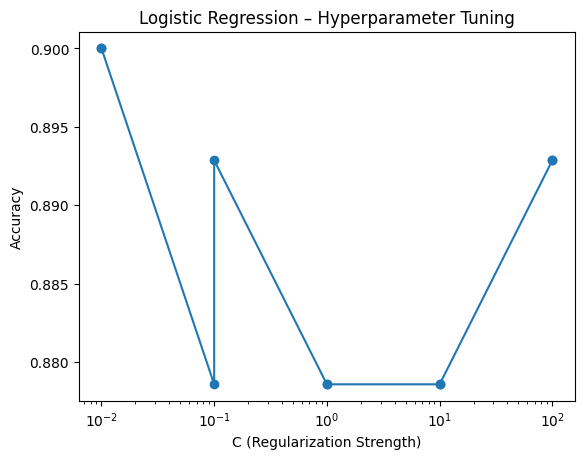

In [105]:
results = pd.DataFrame(log_grid.cv_results_)

plt.figure()
plt.plot(results["param_model__C"], results["mean_test_score"], marker="o")
plt.xscale("log")
plt.xlabel("C (Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Logistic Regression – Hyperparameter Tuning")
plt.show()

### 2. K-Nearest Neighbors

In [106]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", KNeighborsClassifier())
])


knn_params = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"]
}


knn_grid = GridSearchCV(
    knn_pipe,
    knn_params,
    cv=5,
    scoring="accuracy"
)

knn_grid.fit(xctrain, yctrain)
best_knn = knn_grid.best_estimator_


evaluate_model(best_knn, xctest, yctest, "KNN")


KNN
Accuracy: 0.9142857142857143
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         2
         Low       0.91      1.00      0.95        30
      Medium       0.00      0.00      0.00         3

    accuracy                           0.91        35
   macro avg       0.64      0.67      0.65        35
weighted avg       0.84      0.91      0.87        35



0.9142857142857143

### 3. Naive Bayes

In [107]:
from sklearn.naive_bayes import GaussianNB

gnb_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GaussianNB())
])


gnb_params = {
    "model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
}


gnb_grid = GridSearchCV(
    gnb_pipe,
    gnb_params,
    cv=5,
    scoring="accuracy"
)

gnb_grid.fit(xctrain, yctrain)
best_gnb = gnb_grid.best_estimator_


evaluate_model(best_gnb, xctest, yctest, "Gaussian Naive Bayes")


Gaussian Naive Bayes
Accuracy: 0.7714285714285715
              precision    recall  f1-score   support

        High       0.33      0.50      0.40         2
         Low       1.00      0.80      0.89        30
      Medium       0.25      0.67      0.36         3

    accuracy                           0.77        35
   macro avg       0.53      0.66      0.55        35
weighted avg       0.90      0.77      0.82        35



0.7714285714285715

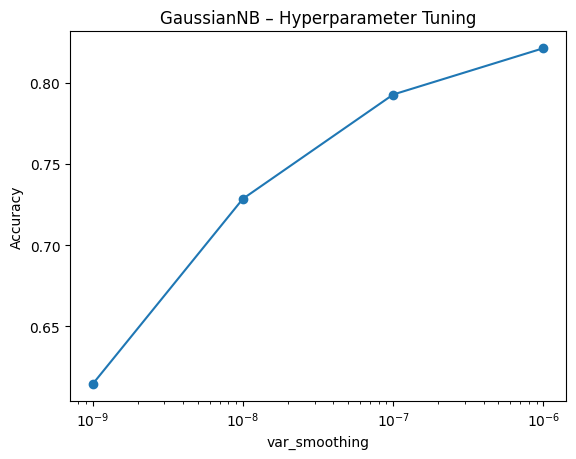

In [108]:
results = pd.DataFrame(gnb_grid.cv_results_)

plt.figure()
plt.plot(results["param_model__var_smoothing"], results["mean_test_score"], marker="o")
plt.xscale("log")
plt.xlabel("var_smoothing")
plt.ylabel("Accuracy")
plt.title("GaussianNB – Hyperparameter Tuning")
plt.show()

### 4. Decision Tree

In [109]:
from sklearn.tree import DecisionTreeClassifier

dt_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])


dt_params = {
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10]
}


dt_grid = GridSearchCV(
    dt_pipe,
    dt_params,
    cv=5,
    scoring="accuracy"
)

dt_grid.fit(xctrain, yctrain)
best_dt = dt_grid.best_estimator_


evaluate_model(best_dt, xctest, yctest, "Decision Tree")


Decision Tree
Accuracy: 0.9142857142857143
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         2
         Low       0.91      1.00      0.95        30
      Medium       0.00      0.00      0.00         3

    accuracy                           0.91        35
   macro avg       0.64      0.67      0.65        35
weighted avg       0.84      0.91      0.87        35



0.9142857142857143

### 5. Support Vector Machine(SVC)

In [110]:
from sklearn.svm import SVC

svc_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", SVC())
])


svc_params = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}


svc_grid = GridSearchCV(
    svc_pipe,
    svc_params,
    cv=5,
    scoring="accuracy"
)

svc_grid.fit(xctrain, yctrain)
best_svc = svc_grid.best_estimator_


evaluate_model(best_svc, xctest, yctest, "Support Vector Classifier")


Support Vector Classifier
Accuracy: 0.9428571428571428
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         2
         Low       0.97      0.97      0.97        30
      Medium       0.67      0.67      0.67         3

    accuracy                           0.94        35
   macro avg       0.88      0.88      0.88        35
weighted avg       0.94      0.94      0.94        35



0.9428571428571428

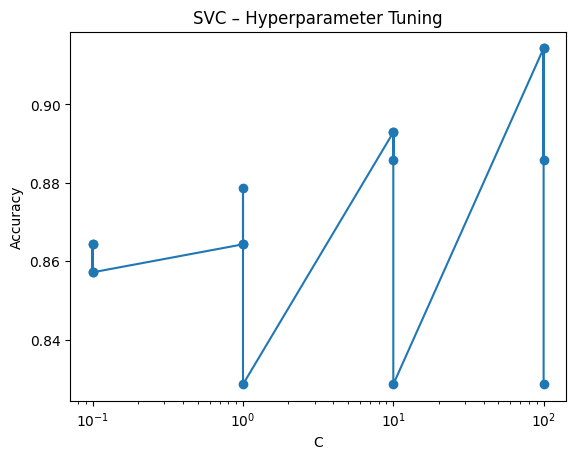

In [111]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(svc_grid.cv_results_)

plt.figure()
plt.plot(results["param_model__C"], results["mean_test_score"], marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("SVC – Hyperparameter Tuning")
plt.show()

### 6. Random Forest

In [112]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])


rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}


rf_grid = GridSearchCV(
    rf_pipe,
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(xctrain, yctrain)
best_rf = rf_grid.best_estimator_


evaluate_model(best_rf, xctest, yctest, "Random Forest")


Random Forest
Accuracy: 0.8857142857142857
              precision    recall  f1-score   support

        High       1.00      0.50      0.67         2
         Low       0.94      0.97      0.95        30
      Medium       0.33      0.33      0.33         3

    accuracy                           0.89        35
   macro avg       0.76      0.60      0.65        35
weighted avg       0.89      0.89      0.88        35



0.8857142857142857

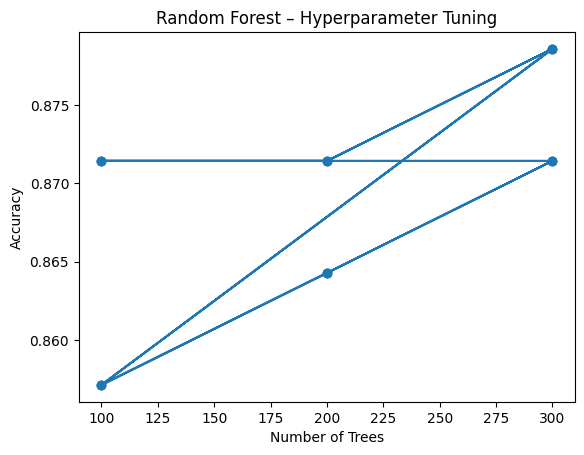

In [113]:
results = pd.DataFrame(rf_grid.cv_results_)

plt.figure()
plt.plot(results["param_model__n_estimators"], results["mean_test_score"], marker="o")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest – Hyperparameter Tuning")
plt.show()

### 7. Gradient Boosting

In [114]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])


gb_params = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.01, 0.1],
    "model__max_depth": [3, 5]
}


gb_grid = GridSearchCV(
    gb_pipe,
    gb_params,
    cv=5,
    scoring="accuracy"
)

gb_grid.fit(xctrain, yctrain)
best_gb = gb_grid.best_estimator_


evaluate_model(best_gb, xctest, yctest, "Gradient Boosting")


Gradient Boosting
Accuracy: 0.8571428571428571
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         2
         Low       0.86      1.00      0.92        30
      Medium       0.00      0.00      0.00         3

    accuracy                           0.86        35
   macro avg       0.29      0.33      0.31        35
weighted avg       0.73      0.86      0.79        35



0.8571428571428571

In [115]:
import pandas as pd
from sklearn.metrics import accuracy_score

final_results = pd.DataFrame([
    ["Logistic Regression", accuracy_score(yctest, best_log.predict(xctest))],
    ["KNN", accuracy_score(yctest, best_knn.predict(xctest))],
    ["Decision Tree", accuracy_score(yctest, best_dt.predict(xctest))],
    ["Random Forest", accuracy_score(yctest, best_rf.predict(xctest))],
    ["Gradient Boosting", accuracy_score(yctest, best_gb.predict(xctest))],
    ["SVC", accuracy_score(yctest, best_svc.predict(xctest))],
    ["GaussianNB", accuracy_score(yctest, best_gnb.predict(xctest))]
], columns=["Model", "Accuracy"])

final_results.sort_values("Accuracy", ascending=False)


,Model,Accuracy
5,SVC,0.942857
0,Logistic Regression,0.914286
1,KNN,0.914286
2,Decision Tree,0.914286
3,Random Forest,0.885714
4,Gradient Boosting,0.857143
6,GaussianNB,0.771429


In [116]:
best_model = best_rf   # or best_log, best_svc, best_gb, etc.

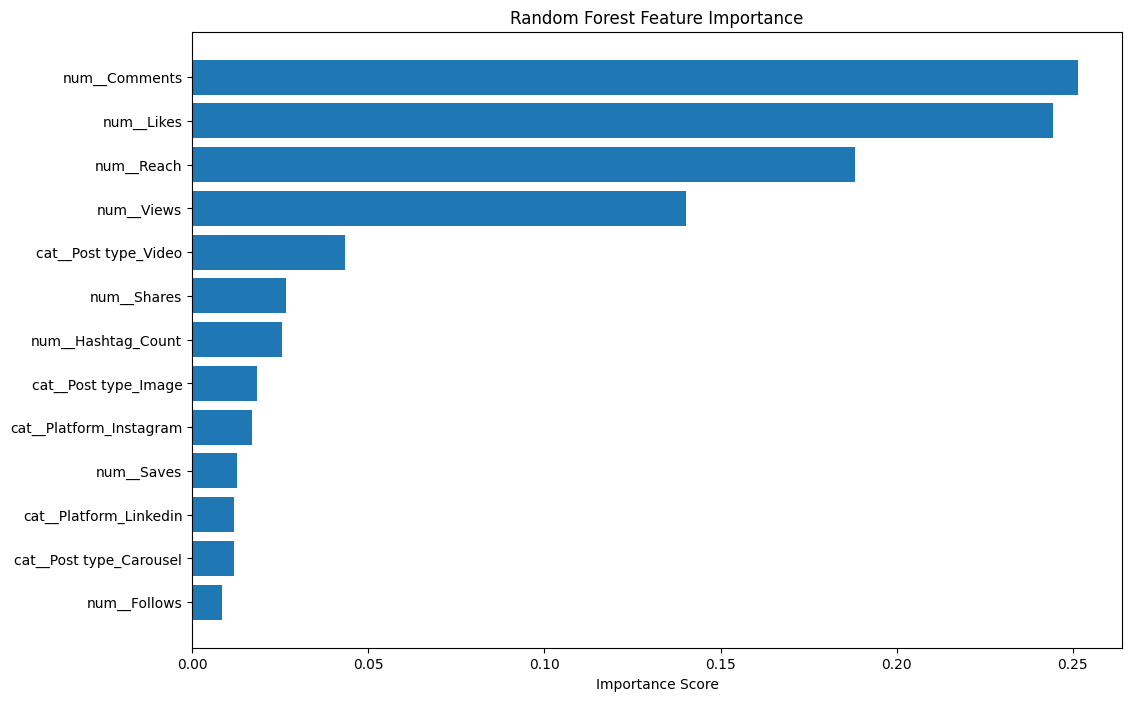

In [117]:
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Extract model inside pipeline
rf_model = best_model.named_steps["model"]

# 2️⃣ Get feature importances
importance = rf_model.feature_importances_

# 3️⃣ Get feature names AFTER preprocessing
preprocessor = best_model.named_steps["preprocessing"]
feature_names = preprocessor.get_feature_names_out()

# 4️⃣ Sort features
indices = np.argsort(importance)

# 5️⃣ Plot
plt.figure(figsize=(12,8))
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()


## CLASSIFICATION MANUAL TESTING (Risk Regime)

#### Low Quality Contents → Low | 🟡 Medium Quality Contents → Medium | 🔴 High Quality Contents → High

### Test Case 1 – Low Quality Content

In [118]:
import pandas as pd

low_case = pd.DataFrame([{
    "Platform": "Instagram",
    "Views": 200,
    "Reach": 180,
    "Likes": 5,
    "Shares": 0,
    "Follows": 0,
    "Comments": 1,
    "Saves": 0,
    "Hashtag_Count": 1,
    "Post type": "image",
    "PostType_carousel": False,
    "PostType_image": True,
    "PostType_reel": False
}])

print("Low Quality Content", best_model.predict(low_case))


Low Quality Content ['Low']


### Test Case 2 – Medium Quality Content

In [119]:
medium_case = pd.DataFrame([{
    "Platform": "Instagram",
    "Views": 1200,
    "Reach": 1000,
    "Likes": 120,
    "Shares": 10,
    "Follows": 8,
    "Comments": 15,
    "Saves": 20,
    "Hashtag_Count": 4,
    "Post type": "carousel",
    "PostType_carousel": True,
    "PostType_image": False,
    "PostType_reel": False
}])

print("Medium Quality Content:", best_model.predict(medium_case))


Medium Quality Content: ['Medium']


### Test Case 3 – High Quality Content

In [120]:
high_case = pd.DataFrame([{
    "Platform": "Instagram",
    "Views": 12000,
    "Reach": 10000,
    "Likes": 1800,
    "Shares": 300,
    "Follows": 200,
    "Comments": 250,
    "Saves": 500,
    "Hashtag_Count": 6,
    "Post type": "reel",
    "PostType_carousel": False,
    "PostType_image": False,
    "PostType_reel": True
}])

print("High Quality Content:", best_model.predict(high_case))


High Quality Content: ['Medium']


# Deployment 

In [121]:
EXPECTED_COLUMNS = xctrain.columns.tolist()

def safe_input(df):
    for col in EXPECTED_COLUMNS:
        if col not in df:
            df[col] = None
    return df[EXPECTED_COLUMNS]

In [122]:
import pandas as pd

user_input = pd.DataFrame([{
    "Platform": "Instagram",
    "Views": 1200,
    "Likes": 140,
    "PostType_reel": True
    # MANY fields missing
}])

user_input = safe_input(user_input)

prediction = best_model.predict(user_input)
probability = best_model.predict_proba(user_input)

print(prediction, probability)


['Low'] [[0.13666667 0.64333333 0.22      ]]


# Saving the model for deployment 

In [123]:
import os, joblib

print(os.getcwd())
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "best_model_pipeline.joblib")
print(os.listdir("models"))

c:\Users\Sujitkumar Bharati\ITvedant anaconda files\Graphura\Graphura Social Media DS-DA Project
['.ipynb_checkpoints', 'best_model_pipeline.joblib', 'best_model_v1.joblib']


In [124]:
import sklearn
print(sklearn.__version__)

1.2.2


In [125]:
import sys
print(sys.version)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [126]:
import sys, sklearn, joblib

print(sys.version)
print(sklearn.__version__)

joblib.dump(best_model, "best_model_pipeline.joblib")


3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
1.2.2


['best_model_pipeline.joblib']